<a href="https://colab.research.google.com/github/subudear/deep-learning/blob/main/assignment1_streamlined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# STEP 1: Imports and GPU check**

In [19]:

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GPU available: True
GPU name: Tesla T4
Using device: cuda


**# STEP 2: Mount Google Drive**

In [20]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


**# STEP 3: Extract dataset zip files**

In [21]:
dataset_path = "/content/drive/MyDrive/compx525assign1/cell_cultures"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

for f in os.listdir(dataset_path):
    if f.endswith(".zip"):
        zip_path = os.path.join(dataset_path, f)
        print("Extracting:", zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("Extraction complete")
print("Extracted folders:", os.listdir(extract_path))



Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/test.zip
Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/train.zip
Extraction complete
Extracted folders: ['train', 'test']


**# STEP 4: DEFINE TRAIN AND TEST PATHS**

In [22]:
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"
image_exts = (".jpg", ".jpeg", ".png")

classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Folder classes:", classes)
print("Number of folder classes:", len(classes))

print("Usable image counts per class:")
for c in classes:
    cls_path = os.path.join(train_dir, c)
    count = sum(fname.lower().endswith(image_exts) for fname in os.listdir(cls_path))
    print(c, count)

print("Test images:", len([f for f in os.listdir(test_dir) if f.lower().endswith(image_exts)]))


Folder classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of folder classes: 17
Usable image counts per class:
a 1283
b 4
c 475
d 266
e 117
f 59
g 720
h 5
i 199
j 0
k 12
l 660
m 543
n 91
o 197
p 35
q 29
Test images: 512


**# STEP 5: Set train/test paths and count usable images**

In [23]:
rows = []

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(image_exts):
                rows.append({
                    "filepath": os.path.join(cls_path, fname),
                    "label": cls
                })

train_df = pd.DataFrame(rows)

print(train_df.head())
print("\nTotal usable training images:", len(train_df))
print("\nUsable class counts:")
print(train_df["label"].value_counts().sort_index())

                                   filepath label
0  /content/dataset/train/a/z1640499927.jpg     a
1   /content/dataset/train/a/z134813956.jpg     a
2  /content/dataset/train/a/z1264187383.jpg     a
3   /content/dataset/train/a/z396227037.jpg     a
4  /content/dataset/train/a/z1339160055.jpg     a

Total usable training images: 4695

Usable class counts:
label
a    1283
b       4
c     475
d     266
e     117
f      59
g     720
h       5
i     199
k      12
l     660
m     543
n      91
o     197
p      35
q      29
Name: count, dtype: int64


**# STEP 6: TRAIN / VALIDATION SPLIT**

In [24]:
class_counts = train_df["label"].value_counts()

# Keep singleton classes in training only
singleton_classes = class_counts[class_counts < 2].index.tolist()
singleton_df = train_df[train_df["label"].isin(singleton_classes)].copy()
normal_df = train_df[~train_df["label"].isin(singleton_classes)].copy()

train_split_df, val_split_df = train_test_split(
    normal_df,
    test_size=0.2,
    stratify=normal_df["label"],
    random_state=42
)

train_split_df = pd.concat([train_split_df, singleton_df], ignore_index=True)

print("Train size:", len(train_split_df))
print("Val size:", len(val_split_df))
print("\nTrain split class counts:")
print(train_split_df["label"].value_counts().sort_index())
print("\nVal split class counts:")
print(val_split_df["label"].value_counts().sort_index())

Train size: 3756
Val size: 939

Train split class counts:
label
a    1026
b       3
c     380
d     213
e      94
f      47
g     576
h       4
i     159
k      10
l     528
m     434
n      73
o     158
p      28
q      23
Name: count, dtype: int64

Val split class counts:
label
a    257
b      1
c     95
d     53
e     23
f     12
g    144
h      1
i     40
k      2
l    132
m    109
n     18
o     39
p      7
q      6
Name: count, dtype: int64


**# STEP 7: ENCODE LABELS**

In [25]:
label_to_idx = {
    label: idx for idx, label in enumerate(sorted(train_df["label"].unique()))
}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

effective_classes = sorted(label_to_idx.keys())
print("Usable classes:", effective_classes)
print("Number of usable classes:", len(effective_classes))
print("label_to_idx:", label_to_idx)

train_split_df["label_idx"] = train_split_df["label"].map(label_to_idx)
val_split_df["label_idx"] = val_split_df["label"].map(label_to_idx)

print(train_split_df.head())
print(val_split_df.head())

Usable classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of usable classes: 16
label_to_idx: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'o': 13, 'p': 14, 'q': 15}
                                   filepath label  label_idx
0    /content/dataset/train/l/z65045266.jpg     l         10
1   /content/dataset/train/a/z801104978.jpg     a          0
2  /content/dataset/train/i/z1765970193.jpg     i          8
3   /content/dataset/train/a/z290277335.jpg     a          0
4  /content/dataset/train/a/z1490996116.jpg     a          0
                                      filepath label  label_idx
2879  /content/dataset/train/g/z1090352323.jpg     g          6
3435  /content/dataset/train/l/z1113463263.jpg     l         10
2157   /content/dataset/train/f/z464006913.jpg     f          5
2346  /content/dataset/train/g/z1882146349.jpg     g          6
2367   /content/dataset/train/g/z329102

**# STEP 8: IMAGE TRANSFORMS**

In [26]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**# STEP 9: PYTORCH DATASETS AND DATA LOADERS**

In [27]:
class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        label = self.df.loc[idx, "label_idx"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = ImageDataset(train_split_df, transform=train_transform)
val_dataset = ImageDataset(val_split_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 3756
Validation dataset size: 939


**# STEP 10: LOAD PRETRAINED RESNET50 AND REPLACE FINAL LAYER**

In [28]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
num_classes = len(label_to_idx)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(model.fc)


Linear(in_features=2048, out_features=16, bias=True)


**# STEP 11: PHASE 1 TRAINING - TRAIN FINAL LAYER ONLY**

In [29]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

print("Trainable parameters in phase 1:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Phase 1 | Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Trainable parameters in phase 1:
fc.weight
fc.bias
Phase 1 | Epoch 1/5 | Train Loss: 2.0741 | Train Acc: 0.3150 | Val Acc: 0.3813
Phase 1 | Epoch 2/5 | Train Loss: 1.7804 | Train Acc: 0.4145 | Val Acc: 0.4175
Phase 1 | Epoch 3/5 | Train Loss: 1.6278 | Train Acc: 0.4728 | Val Acc: 0.4409
Phase 1 | Epoch 4/5 | Train Loss: 1.5067 | Train Acc: 0.5186 | Val Acc: 0.4601
Phase 1 | Epoch 5/5 | Train Loss: 1.4280 | Train Acc: 0.5319 | Val Acc: 0.4526


**# STEP 12: PHASE 2 FINE-TUNING - TRAIN LAYER4 + FC**

In [30]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

print("Trainable parameters in phase 2:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Phase 2 | Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Trainable parameters in phase 2:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias
Phase 2 | Epoch 1/5 | Train Loss: 1.1762 | Train Acc: 0.6060 | Val Acc: 0.5815
Phase 2 | Epoch 2/5 | Train Loss: 0.6099 | Train Acc: 0.8206 | Val Acc: 0.5708
Phase 2 | Epoch 3/5 | Train Loss: 0.3118 | Train Acc: 0.9273 | Val Acc: 0.5815
Phase 2 | Epoch 4/5 | Train Loss: 0.1717 | Train Acc: 0.9667 | Val Acc: 0.6070
Phase 2 

**# STEP 13: SAVE CURRENT BEST PHASE 2 MODEL**

In [31]:
save_path = "/content/drive/MyDrive/resnet50_phase2_best.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "label_to_idx": label_to_idx,
    "idx_to_label": idx_to_label
}, save_path)

print("Model saved to:", save_path)

Model saved to: /content/drive/MyDrive/resnet50_phase2_best.pth


**# STEP 14: VALIDATION EVALUATION**

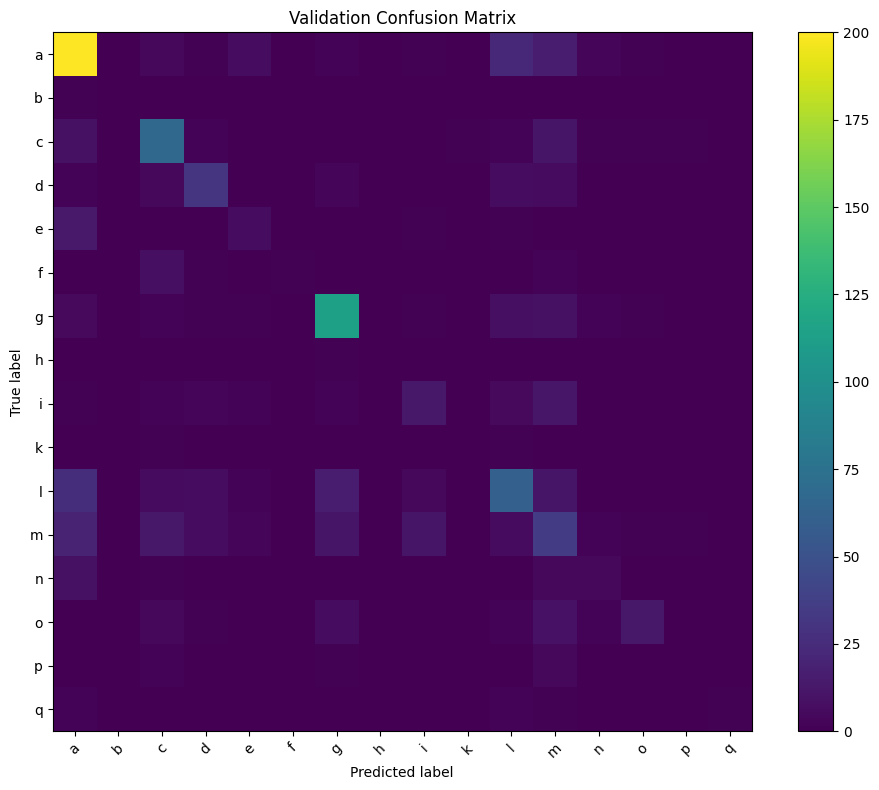

              precision    recall  f1-score   support

           a       0.69      0.78      0.73       257
           b       0.00      0.00      0.00         1
           c       0.59      0.71      0.64        95
           d       0.57      0.58      0.58        53
           e       0.32      0.30      0.31        23
           f       1.00      0.08      0.15        12
           g       0.73      0.79      0.76       144
           h       0.00      0.00      0.00         1
           i       0.42      0.33      0.37        40
           k       0.00      0.00      0.00         2
           l       0.52      0.46      0.49       132
           m       0.29      0.32      0.30       109
           n       0.29      0.22      0.25        18
           o       0.76      0.33      0.46        39
           p       0.00      0.00      0.00         7
           q       1.00      0.17      0.29         6

    accuracy                           0.58       939
   macro avg       0.45   

In [32]:
model.eval()
all_true = []
all_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Validation Confusion Matrix")
plt.colorbar()

class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(classification_report(
    all_true,
    all_pred,
    target_names=class_names,
    zero_division=0
))

**# STEP 15: CREATE TEST DATAFRAME AND TEST DATALOADER**

In [33]:
test_rows = []

for fname in sorted(os.listdir(test_dir)):
    if fname.lower().endswith(image_exts):
        test_rows.append({
            "filepath": os.path.join(test_dir, fname),
            "filename": fname
        })

test_df = pd.DataFrame(test_rows)
print(test_df.head())
print("Total test images:", len(test_df))


class TestImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        filename = self.df.loc[idx, "filename"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, filename


test_dataset = TestImageDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test dataset size:", len(test_dataset))

                                filepath         filename
0    /content/dataset/test/z10002793.jpg    z10002793.jpg
1  /content/dataset/test/z1002467769.jpg  z1002467769.jpg
2  /content/dataset/test/z1002525907.jpg  z1002525907.jpg
3  /content/dataset/test/z1004350237.jpg  z1004350237.jpg
4   /content/dataset/test/z100756404.jpg   z100756404.jpg
Total test images: 512
Test dataset size: 512


**# STEP 16: GENERATE TEST PREDICTION CSV**

In [34]:
model.eval()
all_filenames = []
all_pred_labels = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        pred_labels = [idx_to_label[p.item()] for p in preds]

        all_filenames.extend(filenames)
        all_pred_labels.extend(pred_labels)

submission_df = pd.DataFrame({
    "TestFileName": all_filenames,
    "Class": all_pred_labels
})

csv_path = "/content/drive/MyDrive/resnet50_submission.csv"
submission_df.to_csv(csv_path, index=False)

print(submission_df.head())
print("Saved to:", csv_path)

      TestFileName Class
0    z10002793.jpg     l
1  z1002467769.jpg     l
2  z1002525907.jpg     a
3  z1004350237.jpg     c
4   z100756404.jpg     i
Saved to: /content/drive/MyDrive/resnet50_submission.csv


**# STEP 17: CLASS-WEIGHTED LOSS FOR IMBALANCED DATA**

In [35]:
all_class_indices = list(range(len(label_to_idx)))
class_counts = train_split_df["label_idx"].value_counts().reindex(all_class_indices, fill_value=0).sort_index()

print("Class counts with all usable classes included:")
print(class_counts)

safe_counts = class_counts.replace(0, 1)
counts_tensor = torch.tensor(safe_counts.values, dtype=torch.float)

class_weights = 1.0 / counts_tensor
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Number of usable classes:", len(label_to_idx))
print("Number of weights:", len(class_weights))
print("Class weights:", class_weights)

Class counts with all usable classes included:
label_idx
0     1026
1        3
2      380
3      213
4       94
5       47
6      576
7        4
8      159
9       10
10     528
11     434
12      73
13     158
14      28
15      23
Name: count, dtype: int64
Number of usable classes: 16
Number of weights: 16
Class weights: tensor([0.0187, 6.3873, 0.0504, 0.0900, 0.2038, 0.4077, 0.0333, 4.7905, 0.1205,
        1.9162, 0.0363, 0.0442, 0.2625, 0.1213, 0.6844, 0.8331],
       device='cuda:0')


**STEP 18 weighted fine-tuning**

In [ ]:


# Rebuild the same ResNet50 model structure
# weights=None because we are loading our saved phase-2 checkpoint next
model = resnet50(weights=None)

# Replace the final layer so output size matches our usable classes
model.fc = nn.Linear(model.fc.in_features, len(label_to_idx))

# Load the best model from STEP 13 (phase-2 model before weighted loss)
checkpoint_path = "/content/drive/MyDrive/resnet50_phase2_best.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load saved weights into the model
model.load_state_dict(checkpoint["model_state_dict"])

# Move model to GPU or CPU
model = model.to(device)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last ResNet block so higher-level features can adapt
for param in model.layer4.parameters():
    param.requires_grad = True

# Keep the final classification layer trainable
for param in model.fc.parameters():
    param.requires_grad = True

# Use weighted cross-entropy loss from STEP 17
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer will update only the trainable parameters (layer4 + fc)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

# Track the best validation accuracy and save only the best epoch
best_val_acc = 0.0
best_model_path = "/content/drive/MyDrive/resnet50_weighted_best.pth"

# Number of weighted fine-tuning epochs
num_epochs = 5

for epoch in range(num_epochs):
    # ---------------------------
    # Training phase
    # ---------------------------
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        # Move batch to device
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute weighted loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate training loss
        running_loss += loss.item()

        # Get predicted class
        _, preds = torch.max(outputs, 1)

        # Update training accuracy counts
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # Compute training metrics for this epoch
    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    # ---------------------------
    # Validation phase
    # ---------------------------
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            # Move validation batch to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Get predicted class
            _, preds = torch.max(outputs, 1)

            # Update validation accuracy counts
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Compute validation accuracy
    val_acc = val_correct / val_total

    # Save the best model only
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "label_to_idx": label_to_idx,
                "idx_to_label": idx_to_label,
                "best_val_acc": best_val_acc
            },
            best_model_path
        )
        print(f"Saved new best weighted model at epoch {epoch+1}")

    # Print epoch summary
    print(
        f"Weighted FT | Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
    )

print("\nBest weighted validation accuracy:", best_val_acc)
print("Best weighted model saved to:", best_model_path)

Saved new best weighted model at epoch 1
Weighted FT | Epoch 1/5 | Train Loss: 0.0936 | Train Acc: 0.9864 | Val Acc: 0.5644
